# Giai đoạn 5: Đánh giá & thực nghiệm (barem **1,5 điểm**)

Notebook này tổng hợp **đánh giá toàn diện** cho CineSen, căn chỉnh trực tiếp với ba hạng mục trong rubric:

| Hạng mục barem (mỗi mục **0,5 điểm**) | Bạn trình bày ở notebook này |
|--------------------------------------|-----------------------------|
| **Chỉ số định lượng** phù hợp task | **Gợi ý phim (IR):** Precision@K, Recall@K, NDCG@K từ `eval_results.json` (notebook 03); thêm ablation lexical / semantic / TF-IDF fusion. **ABSA:** micro-F1, macro-F1, **accuracy** sentiment `overall` (3 lớp), F1 theo từng cặp aspect×sentiment. |
| **Minh họa trực quan** | Bảng so sánh model; **hai** biểu đồ cột (NDCG@10, Precision@10); heatmap confusion (proxy IR nếu có; ABSA 3×3); bảng **ví dụ dự đoán** trên tập val. |
| **Thảo luận kết quả** | Ý nghĩa số liệu; **hạn chế** (pseudo-label, weak supervision genre); **hướng cải thiện** — có ô tóm tắt ở cuối notebook. |

**Vì sao không dùng BLEU / ROUGE?** Hai metric đó đo mức tương đồng chuỗi cho **sinh văn** (tóm tắt, dịch máy). Đồ án này là **truy xuất (ranking phim)** và **phân loại đa nhãn (ABSA)**, nên báo cáo dùng **P@K / NDCG@K** và **F1** là đúng chuẩn NLP cho từng task.

**Đầu vào cần có**

- `eval_results.json` — chạy xong **03_Modeling_Baselines.ipynb**
- `absa/absa_eval.json` — chạy xong **04_Advanced_ABSA_Modeling.ipynb** (export eval)
- `cleaned_profiles.csv` — cho cell **ablation** cuối

Sau mỗi lần train lại 03/04, **chạy lại toàn bộ notebook này** để cập nhật bảng và hình.

**Lưu ý hệ thống (ngoài notebook):** runtime web hiện chỉ dùng `POST /recommendations/search` theo chế độ **artifact-only**. Phần định lượng chính vẫn là file JSON từ 03/04; nếu cần so sánh thêm, hãy đối chiếu artifact recommender với các baseline cosine hoặc ablation trong notebook thay vì dùng một pipeline runtime riêng.


=== BẢNG SO SÁNH MODEL (metric thật — Precision@K / Recall@K / NDCG@K) ===


,model,type,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
2,tfidf_uni_bigram_min2,tfidf,0.809593,0.002722,0.814476,0.804797,0.005379,0.809639
1,tfidf_uni_bigram,tfidf,0.806465,0.002634,0.811049,0.799166,0.005214,0.804487
0,tfidf_unigram,tfidf,0.766215,0.002166,0.769778,0.749948,0.004165,0.757306
4,w2v_dim100,word2vec,0.696559,0.001803,0.704981,0.675704,0.003438,0.687392
3,w2v_dim50,word2vec,0.686966,0.001809,0.692321,0.662252,0.003450,0.673311


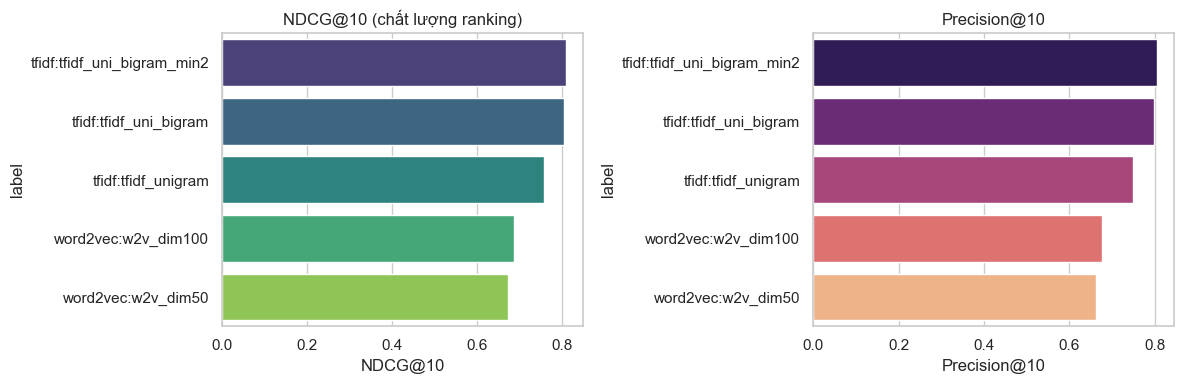


=== Gợi ý trích vào báo cáo (định lượng — IR) ===
- Precision@K / Recall@K / NDCG@K: chuẩn đánh giá information retrieval khi có tập relevant (ở đây: weak supervision theo overlap thể loại — xem notebook 03).
- NDCG@K phạt thứ tự xếp hạng sai (phù hợp danh sách gợi ý có thứ tự).

(Không có `confusion@10` hoặc ma trận toàn 0 trong eval_results.json — bỏ qua heatmap IR; minh họa IR vẫn gồm bảng metric + hai biểu đồ NDCG@10 / Precision@10.)

=== GỢI Ý THẢO LUẬN KẾT QUẢ (dán vào report) ===
- Mô hình tốt nhất theo NDCG@10: tfidf:tfidf_uni_bigram_min2 (NDCG@10=0.8096).
- TF-IDF thường mạnh khi review có nhiều từ khoá đặc trưng; Word2Vec trung bình vector có thể mất thông tin khi review dài/đa chủ đề.
- Hạn chế: nhãn relevant dùng weak supervision theo genre overlap nên chưa phản ánh 100% sở thích người dùng.
- Hướng cải thiện: tăng dữ liệu review, thử SentenceTransformer embeddings, và/hoặc xây ground truth relevance bằng đánh giá thủ công.


In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- Load real evaluation results from notebook 03 ---

try:
    with open("eval_results.json", "r", encoding="utf-8") as f:
        configs = json.load(f)
except FileNotFoundError:
    raise FileNotFoundError(
        "Không tìm thấy eval_results.json. Hãy chạy notebook 03_Modeling_Baselines.ipynb trước để sinh kết quả đánh giá."
    )

# --- Build summary table ---
rows = []
for c in configs:
    m = c.get("metrics", {})
    rows.append(
        {
            "model": c.get("model"),
            "type": c.get("type"),
            "precision@5": m.get("precision@5", 0.0),
            "recall@5": m.get("recall@5", 0.0),
            "ndcg@5": m.get("ndcg@5", 0.0),
            "precision@10": m.get("precision@10", 0.0),
            "recall@10": m.get("recall@10", 0.0),
            "ndcg@10": m.get("ndcg@10", 0.0),
        }
    )

summary = pd.DataFrame(rows).sort_values(by=["ndcg@10", "ndcg@5"], ascending=False)
print("=== BẢNG SO SÁNH MODEL (metric thật — Precision@K / Recall@K / NDCG@K) ===")
display(summary)

# --- Visual: NDCG@10 và Precision@10 (hue=label tránh cảnh báo seaborn) ---
plot_df = summary.copy()
plot_df["label"] = plot_df["type"].astype(str) + ":" + plot_df["model"].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.35 * len(plot_df))))
sns.barplot(
    data=plot_df, x="ndcg@10", y="label", hue="label", palette="viridis", legend=False, ax=axes[0]
)
axes[0].set_title("NDCG@10 (chất lượng ranking)")
axes[0].set_xlabel("NDCG@10")
sns.barplot(
    data=plot_df, x="precision@10", y="label", hue="label", palette="magma", legend=False, ax=axes[1]
)
axes[1].set_title("Precision@10")
axes[1].set_xlabel("Precision@10")
plt.tight_layout()
plt.show()

print("\n=== Gợi ý trích vào báo cáo (định lượng — IR) ===")
print("- Precision@K / Recall@K / NDCG@K: chuẩn đánh giá information retrieval khi có tập relevant (ở đây: weak supervision theo overlap thể loại — xem notebook 03).")
print("- NDCG@K phạt thứ tự xếp hạng sai (phù hợp danh sách gợi ý có thứ tự).")

# --- Confusion-matrix-like (retrieval) for best model at k=10 ---

best = configs[0]
for c in configs:
    if c.get("metrics", {}).get("ndcg@10", 0.0) > best.get("metrics", {}).get("ndcg@10", 0.0):
        best = c

best_name = f"{best.get('type')}:{best.get('model')}"
conf = best.get("metrics", {}).get("confusion@10") or {}
tp, fp, fn, tn = (conf.get(k, 0) or 0 for k in ("tp", "fp", "fn", "tn"))
cm_retrieval = np.array([[tp, fp], [fn, tn]])

if isinstance(conf, dict) and cm_retrieval.sum() > 0:
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_retrieval, annot=True, fmt="d", cmap="Blues")
    plt.title(
        f"Confusion-like matrix (k=10) • {best_name}\n(relevant=shared genres, weak supervision)"
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["Relevant", "Not relevant"])
    plt.yticks([0.5, 1.5], ["Relevant", "Not relevant"], rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(
        "\n(Không có `confusion@10` hoặc ma trận toàn 0 trong eval_results.json — bỏ qua heatmap IR; "
        "minh họa IR vẫn gồm bảng metric + hai biểu đồ NDCG@10 / Precision@10.)"
    )

# --- Discussion template (auto-generated bullet points) ---

print("\n=== GỢI Ý THẢO LUẬN KẾT QUẢ (dán vào report) ===")
print(f"- Mô hình tốt nhất theo NDCG@10: {best_name} (NDCG@10={best.get('metrics', {}).get('ndcg@10', 0.0):.4f}).")
print("- TF-IDF thường mạnh khi review có nhiều từ khoá đặc trưng; Word2Vec trung bình vector có thể mất thông tin khi review dài/đa chủ đề.")
print("- Hạn chế: nhãn relevant dùng weak supervision theo genre overlap nên chưa phản ánh 100% sở thích người dùng.")
print("- Hướng cải thiện: tăng dữ liệu review, thử SentenceTransformer embeddings, và/hoặc xây ground truth relevance bằng đánh giá thủ công.")


## Checklist barem **Đánh giá & thực nghiệm** (1,5 điểm)

Sau khi chạy các ô phía trên, đối chiếu nhanh với đề:

| Tiêu chí (0,5 điểm) | Đã có trong notebook? |
|---------------------|-------------------------|
| **Chỉ số định lượng** phù hợp task | IR: P@K, R@K, NDCG@K (+ ablation ở ô cuối). ABSA: micro/macro-F1, **accuracy** sentiment overall, F1 theo nhãn. |
| **Minh họa** | Bảng so sánh; 2 biểu đồ cột; heatmap ABSA 3×3; heatmap IR **chỉ khi** JSON có `confusion@10`; ví dụ dự đoán val. |
| **Thảo luận** | Các khối `GỢI Ý THẢO LUẬN` in ra bullet → chép vào báo cáo; ô tóm tắt tổng hợp **ở cuối notebook**. |


=== ABSA METRICS (pseudo-label) ===
model: prajjwal1/bert-tiny
n_total=9472 | n_train=7578 | n_val=1894
micro-F1=0.5774 | macro-F1=0.3827

=== ABSA: F1 theo nhãn (aspect×sentiment) ===


,aspect,sentiment,f1
20,overall,positive,0.820077
5,acting,positive,0.684858
2,script,positive,0.682866
19,overall,neutral,0.609558
14,pacing,positive,0.550301
8,visuals,positive,0.540373
17,direction,positive,0.513986
18,overall,negative,0.466877
11,music,positive,0.429942
1,script,neutral,0.423012


accuracy (sentiment overall, 3 lớp)=0.7286


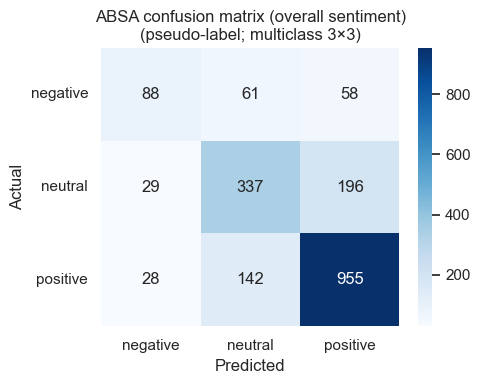


=== Ví dụ dự đoán (val samples) ===


,text,true_labels,pred_labels
0,the god of thunder returns in marvel studios t...,"[acting:positive, visuals:positive, music:posi...","[script:positive, acting:positive, visuals:pos..."
1,one of the goriest films ever made a survivor ...,"[script:positive, acting:positive, visuals:pos...","[script:neutral, acting:neutral, overall:neutral]"
2,damsel suffers from the same issues that plagu...,"[script:negative, acting:negative, visuals:neg...","[script:negative, acting:negative, visuals:neg..."
3,yeah i'm solidly in the from russia with love ...,[overall:positive],"[acting:positive, overall:positive]"
4,round movie good story great cast impressive s...,"[script:positive, acting:positive, overall:pos...","[script:positive, acting:positive, overall:pos..."
5,skyfall was a solid movie in its own right but...,"[script:positive, overall:positive]","[script:neutral, overall:neutral]"
6,of the two sicario films the first is most cer...,[overall:positive],"[script:positive, acting:positive, visuals:pos..."
7,really good comedy following the typical situa...,[overall:positive],"[acting:positive, overall:positive]"



=== GỢI Ý THẢO LUẬN ABSA ===
- micro-F1 thường cao hơn macro-F1 vì dữ liệu/nhãn mất cân bằng (overall xuất hiện ở mọi mẫu; một số nhãn hiếm).
- Hạn chế: pseudo-label gán 1 sentiment chung cho toàn câu rồi áp cho nhiều aspect → chưa phản ánh sentiment riêng từng aspect.
- Hướng cải thiện: gán nhãn tay một phần (gold), hoặc dùng model ABSA pretrain để tạo pseudo-label tốt hơn; tách câu theo sentence.


In [2]:
# --- Load ABSA evaluation results from notebook 04 (exported json) ---
from pathlib import Path

absa_eval_path = Path("absa") / "absa_eval.json"
if absa_eval_path.exists():
    with absa_eval_path.open("r", encoding="utf-8") as f:
        absa_eval = json.load(f)

    print("=== ABSA METRICS (pseudo-label) ===")
    print(f"model: {absa_eval.get('model')}")
    print(f"n_total={absa_eval.get('n_total')} | n_train={absa_eval.get('n_train')} | n_val={absa_eval.get('n_val')}")
    print(f"micro-F1={absa_eval.get('micro_f1'):.4f} | macro-F1={absa_eval.get('macro_f1'):.4f}")

    # Table: per-label F1
    per_label = pd.DataFrame(absa_eval.get("per_label_f1", []))
    per_label = per_label.sort_values(by="f1", ascending=False)
    print("\n=== ABSA: F1 theo nhãn (aspect×sentiment) ===")
    display(per_label)

    # Confusion matrix 3x3 for overall sentiment
    cm = np.array(absa_eval.get("overall_sentiment_cm", [[0, 0, 0], [0, 0, 0], [0, 0, 0]]))
    sentiments = absa_eval.get("sentiments", ["negative", "neutral", "positive"])
    tot_cm = float(cm.sum())
    acc_overall = float(np.trace(cm)) / tot_cm if tot_cm > 0 else 0.0
    print(f"accuracy (sentiment overall, 3 lớp)={acc_overall:.4f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("ABSA confusion matrix (overall sentiment)\n(pseudo-label; multiclass 3×3)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5, 2.5], sentiments)
    plt.yticks([0.5, 1.5, 2.5], sentiments, rotation=0)
    plt.tight_layout()
    plt.show()

    # Sample predictions
    print("\n=== Ví dụ dự đoán (val samples) ===")
    samples = pd.DataFrame(absa_eval.get("samples", []))
    display(samples)

    print("\n=== GỢI Ý THẢO LUẬN ABSA ===")
    print("- micro-F1 thường cao hơn macro-F1 vì dữ liệu/nhãn mất cân bằng (overall xuất hiện ở mọi mẫu; một số nhãn hiếm).")
    print("- Hạn chế: pseudo-label gán 1 sentiment chung cho toàn câu rồi áp cho nhiều aspect → chưa phản ánh sentiment riêng từng aspect.")
    print("- Hướng cải thiện: gán nhãn tay một phần (gold), hoặc dùng model ABSA pretrain để tạo pseudo-label tốt hơn; tách câu theo sentence.")
else:
    print("Chưa có ABSA eval: không thấy `absa/absa_eval.json`. Hãy chạy Notebook 04 (cell train thật) để export trước.")


In [3]:
# --- Ablation: lexical vs semantic vs fusion (offline, weak supervision by shared genres) ---
# Mục tiêu: định lượng lợi ích của "multi-field + weighted re-rank" đề xuất ở Notebook 03.

import math
import random
import re
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load profiles
try:
    df = pd.read_csv("cleaned_profiles.csv").fillna("")
except FileNotFoundError:
    raise FileNotFoundError("Không thấy cleaned_profiles.csv. Hãy chạy Notebook 02 trước.")

# Weak relevance: shared genres overlap

def build_genre_relevance(df: pd.DataFrame, min_overlap: int = 1) -> dict[int, set[int]]:
    genres_list = []
    for g in df["genres"].fillna(""):
        parts = [p.strip().lower() for p in str(g).split(",") if p.strip()]
        genres_list.append(set(parts))
    gold: dict[int, set[int]] = {}
    for i, gi in enumerate(genres_list):
        if not gi:
            gold[i] = set()
            continue
        rel = set()
        for j, gj in enumerate(genres_list):
            if i == j:
                continue
            if len(gi.intersection(gj)) >= min_overlap:
                rel.add(j)
        gold[i] = rel
    return gold


def precision_at_k(predicted: list[int], relevant: set[int], k: int) -> float:
    top_k = predicted[:k]
    if not top_k:
        return 0.0
    hit = sum(1 for idx in top_k if idx in relevant)
    return hit / k


def recall_at_k(predicted: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    top_k = predicted[:k]
    hit = sum(1 for idx in top_k if idx in relevant)
    return hit / len(relevant)


def ndcg_at_k(predicted: list[int], relevant: set[int], k: int) -> float:
    if not relevant or k <= 0:
        return 0.0
    top_k = predicted[:k]
    dcg = 0.0
    for rank, idx in enumerate(top_k, start=1):
        if idx in relevant:
            dcg += 1.0 / math.log2(rank + 1)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 1) for r in range(1, ideal_hits + 1))
    return (dcg / idcg) if idcg > 0 else 0.0


def aggregate_metrics(rankings: dict[int, list[int]], gold: dict[int, set[int]], k_values=(5, 10)) -> dict:
    out = {}
    for k in k_values:
        ps, rs, ns = [], [], []
        for q, pred in rankings.items():
            rel = gold.get(q, set())
            ps.append(precision_at_k(pred, rel, k))
            rs.append(recall_at_k(pred, rel, k))
            ns.append(ndcg_at_k(pred, rel, k))
        out[f"precision@{k}"] = float(np.mean(ps)) if ps else 0.0
        out[f"recall@{k}"] = float(np.mean(rs)) if rs else 0.0
        out[f"ndcg@{k}"] = float(np.mean(ns)) if ns else 0.0
    return out


# Scoring functions (same spirit as Notebook 03)

def _norm_tokens(s: str) -> list[str]:
    return [t for t in re.sub(r"[^a-zA-Z0-9\s]+", " ", str(s).lower()).split() if t]


def title_lexical_score(query: str, title: str) -> float:
    q = " ".join(_norm_tokens(query))
    t = " ".join(_norm_tokens(title))
    if not q or not t:
        return 0.0
    ratio = SequenceMatcher(None, q, t).ratio()
    qset = set(q.split())
    tset = set(t.split())
    overlap = (len(qset & tset) / max(1, len(qset))) if qset else 0.0
    return 0.6 * ratio + 0.4 * overlap


def genre_keyword_score(query: str, genres_str: str) -> float:
    q_tokens = set(_norm_tokens(query))
    if not q_tokens:
        return 0.0
    genres = {g.strip().lower() for g in str(genres_str).split(",") if g and g.strip()}
    if not genres:
        return 0.0
    genre_tokens = set()
    for g in genres:
        genre_tokens.update(_norm_tokens(g))
    hits = sum(1 for tok in q_tokens if tok in genre_tokens)
    return hits / max(1, len(q_tokens))


def choose_weights(query: str) -> tuple[float, float, float]:
    n = len(_norm_tokens(query))
    if n <= 3:
        return (1.0, 0.8, 0.3)
    if n <= 6:
        return (0.7, 0.8, 0.6)
    return (0.2, 0.8, 1.0)


# Semantic TF-IDF index on movie_profile (fallback)
semantic_col = "movie_profile" if "movie_profile" in df.columns else ("review_profile" if "review_profile" in df.columns else "overview")
semantic_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.9)
X = semantic_vectorizer.fit_transform(df[semantic_col].astype(str).tolist())


def semantic_scores(query: str) -> np.ndarray:
    qv = semantic_vectorizer.transform([str(query)])
    sims = cosine_similarity(qv, X).ravel()
    mx = float(sims.max()) if sims.size else 0.0
    return sims / mx if mx > 0 else sims


# Build gold relevance
GOLD = build_genre_relevance(df, min_overlap=1)

# Build evaluation queries: use movie title+genres as a "proxy query" for offline testing
rng = random.Random(42)
all_idx = list(range(len(df)))
rng.shuffle(all_idx)
EVAL_N = min(300, len(all_idx))
query_idx = all_idx[:EVAL_N]

rank_lex = {}
rank_sem = {}
rank_fusion = {}

for qi in query_idx:
    title = str(df.loc[qi, "title"])
    genres = str(df.loc[qi, "genres"])
    query = f"{title} {genres}".strip()

    # compute component scores for all candidates
    # NOTE: use .copy() to ensure arrays are writable (avoid "assignment destination is read-only").
    ts = df["title"].apply(lambda t: title_lexical_score(query, t)).to_numpy(dtype=float).copy()
    gs = df["genres"].apply(lambda g: genre_keyword_score(query, g)).to_numpy(dtype=float).copy()
    ss = semantic_scores(query).copy()

    # exclude self
    ts[qi] = -1
    gs[qi] = -1
    ss[qi] = -1

    w_title, w_genre, w_sem = choose_weights(query)
    fused = (w_title * ts) + (w_genre * gs) + (w_sem * ss)

    rank_lex[qi] = list(np.argsort((ts + gs))[::-1])
    rank_sem[qi] = list(np.argsort(ss)[::-1])
    rank_fusion[qi] = list(np.argsort(fused)[::-1])

print("\n=== Ablation (weak supervision: shared genres) ===")
rows = []
for name, ranking in [
    ("lexical_only(title+genre)", rank_lex),
    ("semantic_only(tfidf)", rank_sem),
    ("fusion(weighted)", rank_fusion),
]:
    m = aggregate_metrics(ranking, GOLD, k_values=(5, 10))
    rows.append({"model": name, **m})

abl = pd.DataFrame(rows).sort_values(by="ndcg@10", ascending=False)
display(abl)

print("\nGợi ý diễn giải:")
print("- lexical_only mạnh cho query giống title/genre; semantic_only bắt ngữ nghĩa rộng hơn nhưng dễ nhiễu; fusion thường cân bằng hơn.")
print("- Lưu ý: metric dùng weak supervision theo genre overlap nên chỉ là proxy, không phải ground-truth sở thích user.")

# --- Qualitative: ABSA bonus (requires Notebook 04 export) ---
profiles_path = Path("absa") / "absa_movie_profiles.json"
if profiles_path.exists():
    import json

    movie_profiles = json.loads(profiles_path.read_text(encoding="utf-8"))
    print(f"\nLoaded ABSA movie profiles: {len(movie_profiles)} movies")
    print("(ABSA bonus nên minh hoạ ở Notebook 06 bằng các query có cảm xúc/aspect cụ thể.)")
else:
    print("\nKhông thấy absa/absa_movie_profiles.json (chạy Notebook 04 để export).")



=== Ablation (weak supervision: shared genres) ===


,model,precision@5,recall@5,ndcg@5,precision@10,recall@10,ndcg@10
0,lexical_only(title+genre),0.995333,0.003623,0.995466,0.994667,0.007098,0.994917
2,fusion(weighted),0.994667,0.003856,0.993840,0.994333,0.007618,0.993846
1,semantic_only(tfidf),0.930000,0.003417,0.925393,0.935333,0.006857,0.930607



Gợi ý diễn giải:
- lexical_only mạnh cho query giống title/genre; semantic_only bắt ngữ nghĩa rộng hơn nhưng dễ nhiễu; fusion thường cân bằng hơn.
- Lưu ý: metric dùng weak supervision theo genre overlap nên chỉ là proxy, không phải ground-truth sở thích user.

Loaded ABSA movie profiles: 2426 movies
(ABSA bonus nên minh hoạ ở Notebook 06 bằng các query có cảm xúc/aspect cụ thể.)


## Bổ sung: LLM-as-a-Judge cho retrieval

Theo góp ý của giảng viên, phần retrieval nên được đánh giá thêm bằng **query bank đa dạng** (`keyword`, `vibe`, `detailed`) và một bước **LLM-as-a-Judge** có rubric rõ ràng.

Luồng offline mới:
- `python -m Notebook_Report.retrieval.build_query_bank`
- `python -m Notebook_Report.retrieval.finetune_biencoder`
- `python -m Notebook_Report.retrieval.eval_llm_judge`

Judge output được lưu thành JSONL/summary để tổng hợp theo `model` và `stratum`; đồng thời script cũng sinh `human_audit_sample.csv` để đối chiếu thủ công 50-100 mẫu.


In [ ]:
from pathlib import Path
import json

import pandas as pd

judge_root = Path("llm_judge_runs")
run_dirs = sorted([p for p in judge_root.glob("*") if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)

if not run_dirs:
    print("Chưa có LLM judge run. Chạy: python -m Notebook_Report.retrieval.eval_llm_judge")
else:
    latest_run = run_dirs[0]
    summary_path = latest_run / "summary.json"
    if not summary_path.exists():
        print(f"{latest_run} chưa có summary.json")
    else:
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        print(f"Latest judge run: {latest_run}")
        print(f"Judge model: {summary.get('judge_model')}")
        print(f"Query count: {summary.get('query_count')}")
        print(f"Judged rows: {summary.get('judged_rows')}")

        by_model = pd.DataFrame(summary.get("by_model", []))
        by_model_stratum = pd.DataFrame(summary.get("by_model_stratum", []))

        if not by_model.empty:
            display(by_model.sort_values(by="mean_relevance_score", ascending=False))
        if not by_model_stratum.empty:
            display(by_model_stratum.sort_values(by=["stratum", "mean_relevance_score"], ascending=[True, False]))

        audit_path = Path(summary.get("human_audit_sample_path") or latest_run / "human_audit_sample.csv")
        if audit_path.exists():
            audit_df = pd.read_csv(audit_path).fillna("")
            print(f"\nHuman audit sample: {audit_path} (rows={len(audit_df)})")
            human_col = audit_df.get("human_binary_relevant")
            if human_col is not None:
                filled = audit_df[human_col.astype(str).str.strip() != ""].copy()
                if not filled.empty:
                    def _to_bool(series: pd.Series) -> pd.Series:
                        return series.astype(str).str.strip().str.lower().map({
                            "true": True,
                            "1": True,
                            "yes": True,
                            "false": False,
                            "0": False,
                            "no": False,
                        })

                    human = _to_bool(filled["human_binary_relevant"])
                    llm = _to_bool(filled["judge_binary_relevant"])
                    valid = human.notna() & llm.notna()
                    if valid.any():
                        agreement = float((human[valid] == llm[valid]).mean())
                        print(f"Human vs LLM agreement: {agreement:.3f} on {int(valid.sum())} annotated rows")
                else:
                    print("Chưa có cột human_* được điền; file này là template để đối chiếu thủ công.")


## Thảo luận tổng hợp (ý nghĩa — hạn chế — hướng phát triển)

**Ý nghĩa:** Kết quả IR (P@K, NDCG@K) cho biết mức độ khớp giữa truy vấn/review và danh sách phim được xếp hạng, dưới góc nhìn **proxy** (overlap thể loại). ABSA (F1, accuracy overall) phản ánh mức độ mô hình tóm tắt **cảm xúc theo khía cạnh** từ review, hỗ trợ làm giàu profile phim cho artifact recommender. Phần **LLM-as-a-Judge** bổ sung thêm góc nhìn semantic có rubric + reasoning, nhất là cho các query `vibe` và `detailed` khó chấm chỉ bằng overlap thể loại.

**Hạn chế chính:** (1) Relevance IR không phải khảo sát người dùng thật. (2) Nhãn ABSA là **pseudo-label / weak supervision** → độ lệch nhãn có thể làm F1/accuracy lạc quan hoặc lệch lớp. (3) Kết quả runtime web còn phụ thuộc artifact export hiện hành, nên không thay thế hoàn toàn eval JSON cố định từ notebook 03/04. (4) LLM judge vẫn là proxy evaluator, vì vậy cần **manual audit sample** 50-100 mẫu để đối chiếu lại với đánh giá thủ công.

**Hướng cải thiện:** Thu thập **gold labels** (relevance hoặc ABSA) trên mẫu nhỏ; mở rộng query bank theo từng loại truy vấn; thử fine-tune thêm bi-encoder/cross-encoder; và nếu triển khai thật thì kết hợp đánh giá online (click, rating) với audit tay định kỳ.
